In [1]:
import matplotlib.pyplot as plt
import numpy as np

from skimage import data, feature
from skimage.color import rgb2gray
from numpy import linalg

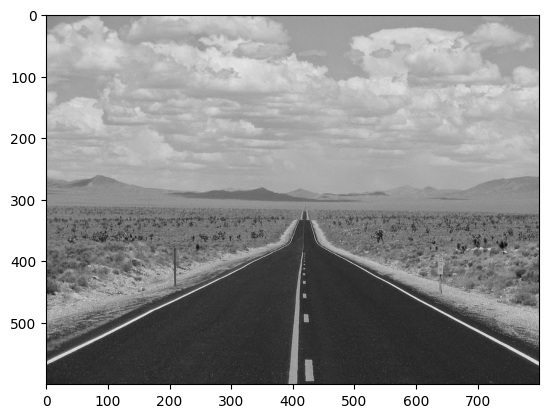

In [2]:
#import the image and detect edges using the canny feature
img1 = color.rgb2gray(io.imread('./figures/input_images/test1.jpg'))

plt.imshow(img1, cmap='gray')

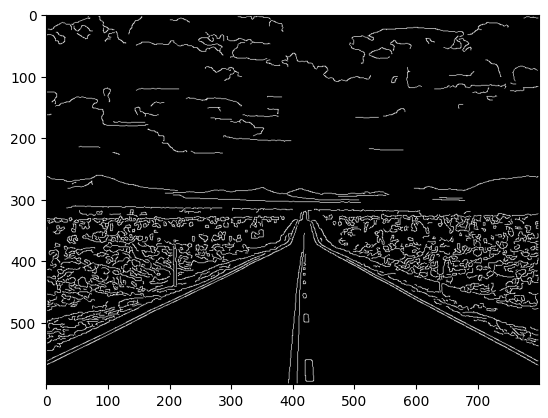

In [10]:
# custom parameters for the canny image filter

# matlab uses a default sigma of sqrt(2), this is much more accurate to an expected matlab output
edge_img1 = feature.canny(img1, sigma=np.sqrt(2))

# this removes most of the image except for the white lines of interest
# only the white lines on the edges of the road are preserved after this
# edge_img1 = feature.canny(img1, sigma=1, low_threshold=0.4, high_threshold=1.2)

plt.imshow(edge_img1, cmap='gray')

# this also makes the hough transform later on to run much faster which takes way less time (from 39.1 seconds to 2.8)

In [ ]:
# sampling freq
theta_sample_frequency = 0.01 
rows, cols = (edge_img1.shape)

# this should stay an integer because stepping by 1 through rho
rho_lim = int(np.ceil(np.linalg.norm([rows, cols])))

# initialize ranges of rho and theta which will be stepped through
rho = np.arange(-rho_lim, rho_lim, 1)
theta = np.arange(0, np.pi, theta_sample_frequency)
num_thetas = len(theta)
num_rhos = len(rho)

# creating an accumulator array with the length of rhos and thetas. 
acc = np.zeros((num_rhos, num_thetas))

## Performing the hough transform
# translating matlab code into python is thankfully very nice because I do not need to worry about row/column indexing
for indrows in range(rows):
    for indcols in range(cols):
        if edge_img1[indrows, indcols] == 1: 
            for theta_max in range(num_thetas):
                th = theta[theta_max]
                r = indrows * np.cos(th) + indcols * np.sin(th)
                
                # this needs to stay an int bc it will go out of bounds otherwise. 
                rho_max = int(round(r + num_rhos/2))     
                acc[rho_max, theta_max] = acc[rho_max, theta_max] + 1


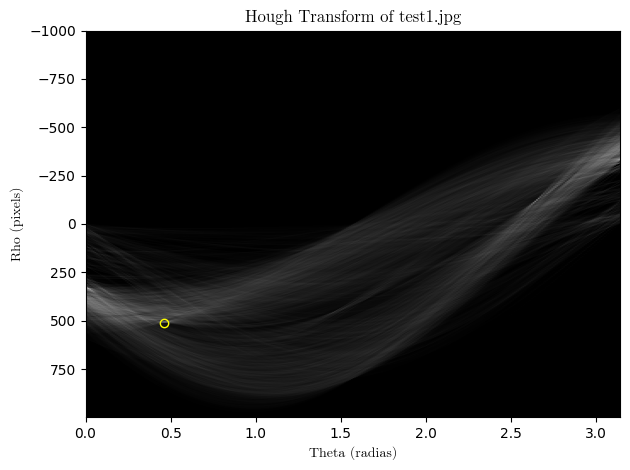

In [ ]:
## plotting the image

# I lied. it is not easy.
extent = [theta[0], theta[-1], rho[-1], rho[0]]


plt.figure()
plt.imshow(acc, extent=extent, aspect='auto', cmap='gray')
plt.title('Hough Transform of test1.jpg', fontname='CMU Serif')
plt.xlabel('Theta (radias)', fontname='CMU Serif')
plt.ylabel('Rho (pixels)', fontname='CMU Serif')

# ind2sub doesn't exist, so here's a workaround: 
I = np.argmax(acc) # grab linear index of max val
M = acc.flat[I] # grab max val

# unravel the index so its not longer a 2 by 2 array
rho_max, theta_max = np.unravel_index(I, acc.shape)

plt.plot(theta[theta_max], rho[rho_max], 'o', fillstyle='none', color='yellow')
plt.tight_layout()
plt.show()

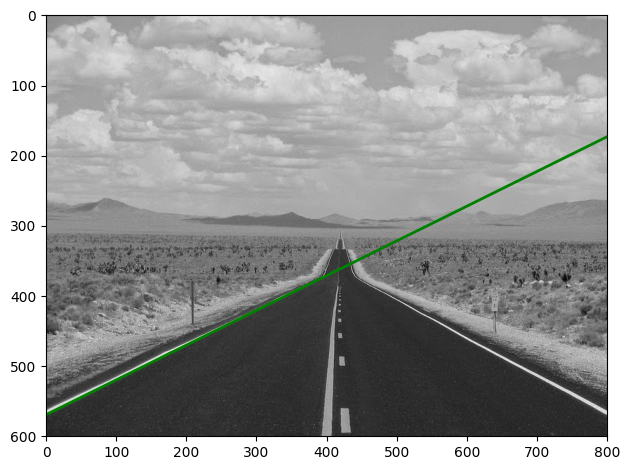

In [ ]:
## drawing the line coordinates over the image
m = - (np.cos(theta[theta_max]) / np.sin(theta[theta_max]))
b = rho[rho_max] / np.sin(theta[theta_max])

x = np.arange(1, cols + 1) # offset of 1 due to python indicing
y = m*x + b

plt.figure()
plt.imshow(img, cmap='gray')
plt.plot(y, x, 'g', linewidth=2)
plt.xlim(0, cols)
plt.ylim(rows, 0)
plt.tight_layout()
plt.show()


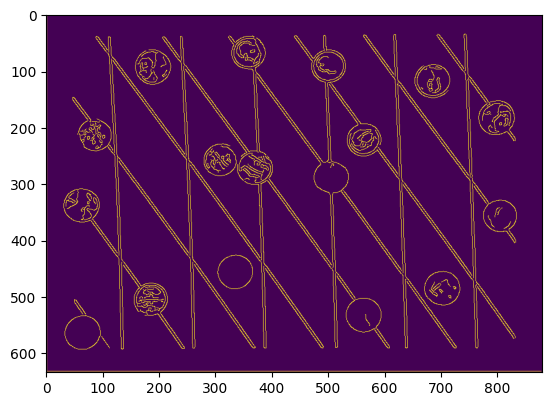

In [8]:
I = io.imread('figures/input_images/test2.jpg')
img = color.rgb2gray(I)
edge_img = feature.canny(img, sigma=np.sqrt(2), low_threshold=0.2, high_threshold=0.4)
plt.imshow(edge_img)

In [ ]:
radius1 = dime_rad
radius2 = penny_rad




theta_sample_frequency = 0.01 
rows, cols = (edge_img.shape)

# despite needing to cast data types, I WILL NOT USE MATLAB
rho_lim = int(np.ceil(np.linalg.norm([rows, cols])))

rho = np.arange(-rho_lim, rho_lim, 1)
theta = np.arange(0, 2 * np.pi, theta_sample_frequency)
num_thetas = len(theta)
num_rhos = len(rho)
acc = np.zeros((num_rhos, num_thetas))
